In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
DATA_PATH = Path(r'C:\Users\user00\Desktop\MCI_Diffusion\src\data\dataset.csv')
OUT_DIR = os.path.join('outputs', 'analysis')
os.makedirs(OUT_DIR, exist_ok=True)


In [3]:
df = pd.read_csv(DATA_PATH)
display(df[['lat','lon','pdr_mean']].describe())

,lat,lon,pdr_mean
count,1575.000000,1575.000000,1575.000000
mean,36.343946,127.389507,0.045999
std,0.066942,0.062471,0.017826
min,36.191453,127.248803,0.006931
25%,36.293132,127.338195,0.031526
50%,36.345801,127.393428,0.045683
75%,36.395493,127.442359,0.057271
max,36.493490,127.536574,0.151781


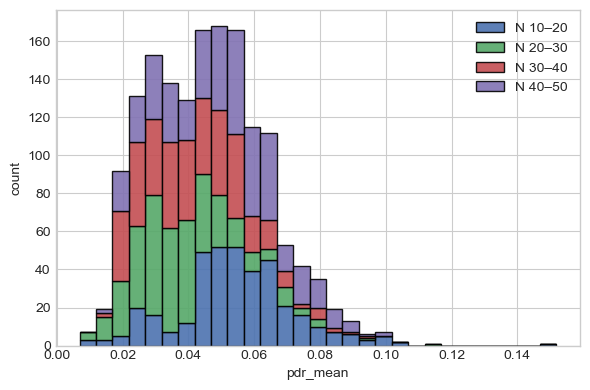

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# pdr_mean, N이 있는 데이터프레임 df 사용
bins = np.linspace(df['pdr_mean'].min(), df['pdr_mean'].max(), 30)

# N 구간별 서브셋
g_10_20 = df[(df['N'] >= 10) & (df['N'] < 20)]['pdr_mean']
g_20_30 = df[(df['N'] >= 20) & (df['N'] < 30)]['pdr_mean']
g_30_40 = df[(df['N'] >= 30) & (df['N'] < 40)]['pdr_mean']
g_40_50 = df[(df['N'] >= 40) & (df['N'] <= 50)]['pdr_mean']

plt.figure(figsize=(6,4))
plt.hist(
    [g_10_20, g_20_30, g_30_40, g_40_50],
    bins=bins,
    stacked=True,          # 막대 안에서 색을 쌓아서 구분
    label=['N 10–20', 'N 20–30', 'N 30–40', 'N 40–50'],
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'],
    edgecolor='black',
    alpha=0.9,
)
plt.xlabel('pdr_mean')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
df_30 = df[(df['N'] >= 27) & (df['N'] <= 33)]
display(df_30.describe())

,lat,lon,pdr_mean,pdr_std,N
count,270.000000,270.000000,270.000000,270.000000,270.000000
mean,36.345868,127.388113,0.039215,0.022813,29.881481
std,0.068047,0.063539,0.013968,0.008637,1.920548
min,36.200070,127.263765,0.012413,0.006829,27.000000
25%,36.299785,127.335646,0.029115,0.016097,28.000000
50%,36.349099,127.391948,0.037839,0.021206,30.000000
75%,36.393378,127.447231,0.049110,0.028349,31.000000
max,36.493490,127.527251,0.093477,0.050528,33.000000


C:\Users\user00\AppData\Local\Temp\ipykernel_23264\3672036046.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


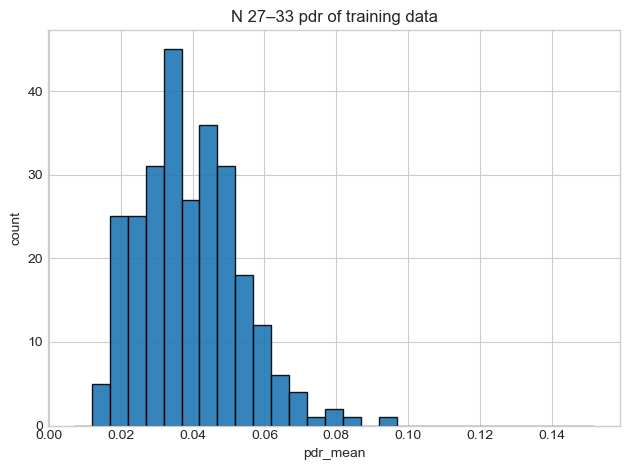

In [39]:
plt.hist(
    [df_30['pdr_mean']],
    bins=bins,
    stacked=True,          
    edgecolor='black',
    alpha=0.9,
)
plt.xlabel('pdr_mean')
plt.ylabel('count')
plt.legend()
plt.title('N 27–33 pdr of training data')
plt.tight_layout()
plt.show()

In [28]:
 # 10개 동일 간격으로 쪼개기
df_30 = df[(df['N'] >= 27) & (df['N'] <= 33)].copy()
pdr_min = df_30['pdr_mean'].min()  # 0.012413
pdr_max = df_30['pdr_mean'].max()  # 0.093477

df_30['q_bin'], bin_edges = pd.cut(
    df_30['pdr_mean'],
    bins=10,
    retbins=True,
    labels=[f'q{i+1}' for i in range(10)]
)

bin_stats = df_30.groupby('q_bin').agg(
    count=('pdr_mean', 'count'),
    pdr_mean=('pdr_mean', 'mean'),
    pdr_std=('pdr_mean', 'std')
).reset_index()

bin_stats['bin_min'] = bin_edges[:-1]
bin_stats['bin_max'] = bin_edges[1:]

# 샘플링 비율 추가
bin_stats['ratio'] = bin_stats['count'] / bin_stats['count'].sum()
bin_stats['sample_num'] = (bin_stats['ratio'] * 2000).astype(int)

print(bin_stats['bin_max']-bin_stats['bin_min'])
bin_stats
#bin_stats.to_csv('bin_stats_n30.csv', index=False)


0    0.008187
1    0.008106
2    0.008106
3    0.008106
4    0.008106
5    0.008106
6    0.008106
7    0.008106
8    0.008106
9    0.008106
dtype: float64


C:\Users\user00\AppData\Local\Temp\ipykernel_23264\1938418796.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_30.groupby('q_bin').agg(


,q_bin,count,pdr_mean,pdr_std,bin_min,bin_max,ratio,sample_num
0,q1,21,0.017986,0.002203,0.012332,0.020519,0.077778,155
1,q2,44,0.024377,0.002441,0.020519,0.028626,0.162963,325
2,q3,65,0.032936,0.002152,0.028626,0.036732,0.240741,481
3,q4,50,0.041200,0.002308,0.036732,0.044838,0.185185,370
4,q5,47,0.048539,0.002276,0.044838,0.052945,0.174074,348
5,q6,26,0.056165,0.002185,0.052945,0.061051,0.096296,192
6,q7,10,0.064321,0.002091,0.061051,0.069157,0.037037,74
7,q8,3,0.071522,0.002549,0.069157,0.077264,0.011111,22
8,q9,3,0.081299,0.001024,0.077264,0.085370,0.011111,22
9,q10,1,0.093477,NaN,0.085370,0.093477,0.003704,7


C:\Users\user00\AppData\Local\Temp\ipykernel_23264\3047787997.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


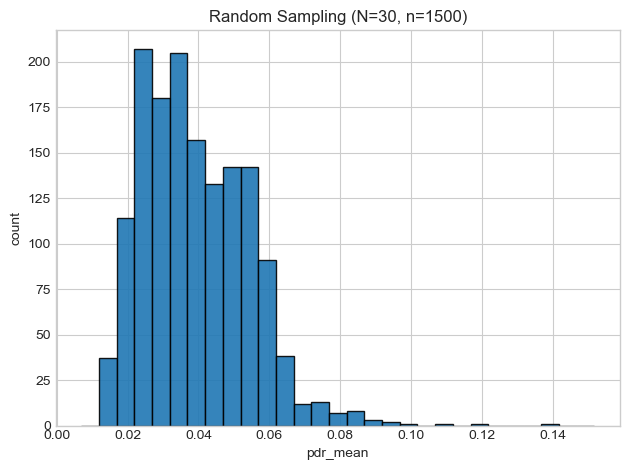

In [36]:
# 랜덤 샘플링 사고규모 30, 1500개 
DATA_PATH = Path(r'C:\Users\user00\Desktop\MCI_Diffusion\src\data\daejeon_30.csv')
df_base = pd.read_csv(DATA_PATH)

plt.hist(
    [df_base['pdr_mean']],
    bins=bins,
    stacked=True,          
    edgecolor='black',
    alpha=0.9,
)
plt.xlabel('pdr_mean')
plt.ylabel('count')
plt.title('Random Sampling (N=30, n=1500)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
 # 10개 동일 간격으로 쪼개기
df_30 = df[(df['N'] >= 27) & (df['N'] <= 33)].copy()
pdr_min = df_30['pdr_mean'].min()  # 0.012413
pdr_max = df_30['pdr_mean'].max()  # 0.093477

df_30['q_bin'], bin_edges = pd.cut(
    df_30['pdr_mean'],
    bins=10,
    retbins=True,
    labels=[f'q{i+1}' for i in range(10)]
)

bin_stats = df_30.groupby('q_bin').agg(
    count=('pdr_mean', 'count'),
    pdr_mean=('pdr_mean', 'mean'),
    pdr_std=('pdr_mean', 'std')
).reset_index()

bin_stats['bin_min'] = bin_edges[:-1]
bin_stats['bin_max'] = bin_edges[1:]

# 샘플링 비율 추가
bin_stats['ratio'] = bin_stats['count'] / bin_stats['count'].sum()
bin_stats['sample_num'] = (bin_stats['ratio'] * 2000).astype(int)

print(bin_stats['bin_max']-bin_stats['bin_min'])
bin_stats
#bin_stats.to_csv('bin_stats_n30.csv', index=False)


0    0.008187
1    0.008106
2    0.008106
3    0.008106
4    0.008106
5    0.008106
6    0.008106
7    0.008106
8    0.008106
9    0.008106
dtype: float64


C:\Users\user00\AppData\Local\Temp\ipykernel_23264\1938418796.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_30.groupby('q_bin').agg(


,q_bin,count,pdr_mean,pdr_std,bin_min,bin_max,ratio,sample_num
0,q1,21,0.017986,0.002203,0.012332,0.020519,0.077778,155
1,q2,44,0.024377,0.002441,0.020519,0.028626,0.162963,325
2,q3,65,0.032936,0.002152,0.028626,0.036732,0.240741,481
3,q4,50,0.041200,0.002308,0.036732,0.044838,0.185185,370
4,q5,47,0.048539,0.002276,0.044838,0.052945,0.174074,348
5,q6,26,0.056165,0.002185,0.052945,0.061051,0.096296,192
6,q7,10,0.064321,0.002091,0.061051,0.069157,0.037037,74
7,q8,3,0.071522,0.002549,0.069157,0.077264,0.011111,22
8,q9,3,0.081299,0.001024,0.077264,0.085370,0.011111,22
9,q10,1,0.093477,NaN,0.085370,0.093477,0.003704,7


In [30]:
import geopandas as gpd
import numpy as np

shp_path = r"C:\Users\user00\Desktop\MCI_Diffusion\MCI_ADV2\scenarios\ctprvn.shp"
gdf = gpd.read_file(shp_path)

candidates = [5179, 5181, 5186, 5187, 5185, 5180]  # 한국에서 자주 쓰는 TM 계열
ok = []

for epsg in candidates:
    try:
        tmp = gdf.set_crs(epsg=epsg, allow_override=True).to_crs(epsg=4326)
        minx, miny, maxx, maxy = tmp.total_bounds  # lon/lat bounds
        in_korea = (124 <= minx <= 132) and (33 <= miny <= 39) and (124 <= maxx <= 132) and (33 <= maxy <= 39)
        print(f"EPSG:{epsg} -> bounds (lon/lat): {minx:.3f}, {miny:.3f}, {maxx:.3f}, {maxy:.3f} | Korea? {in_korea}")
        if in_korea:
            ok.append(epsg)
    except Exception as e:
        print(f"EPSG:{epsg} failed: {e}")

print("Plausible EPSG:", ok)

EPSG:5179 -> bounds (lon/lat): 124.610, 33.114, 131.873, 38.614 | Korea? True
EPSG:5181 -> bounds (lon/lat): 134.639, 46.284, 143.485, 51.433 | Korea? False
EPSG:5186 -> bounds (lon/lat): 134.512, 45.395, 143.192, 50.555 | Korea? False
EPSG:5187 -> bounds (lon/lat): 136.512, 45.395, 145.192, 50.555 | Korea? False
EPSG:5185 -> bounds (lon/lat): 132.512, 45.395, 141.192, 50.555 | Korea? False
EPSG:5180 -> bounds (lon/lat): 132.639, 46.284, 141.485, 51.433 | Korea? False
Plausible EPSG: [5179]


C:\Users\user00\AppData\Local\Temp\ipykernel_23264\503994659.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


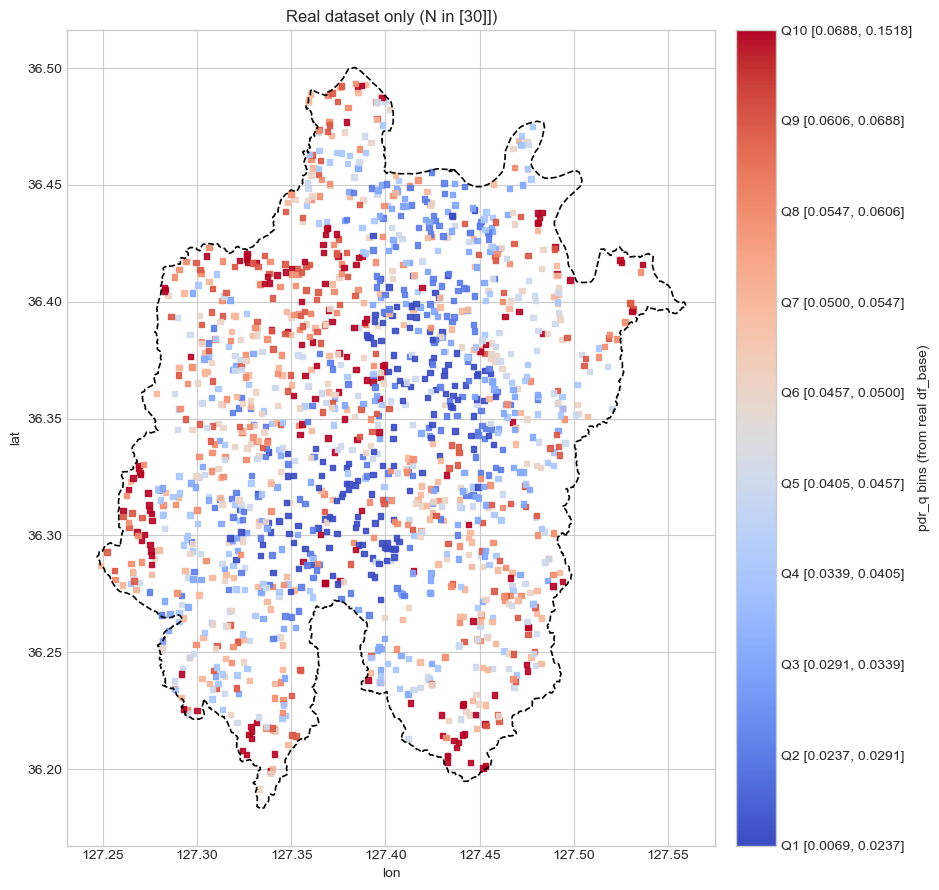

Loaded sample csv count: 10


C:\Users\user00\AppData\Local\Temp\ipykernel_23264\503994659.py:172: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=8, framealpha=0.9)


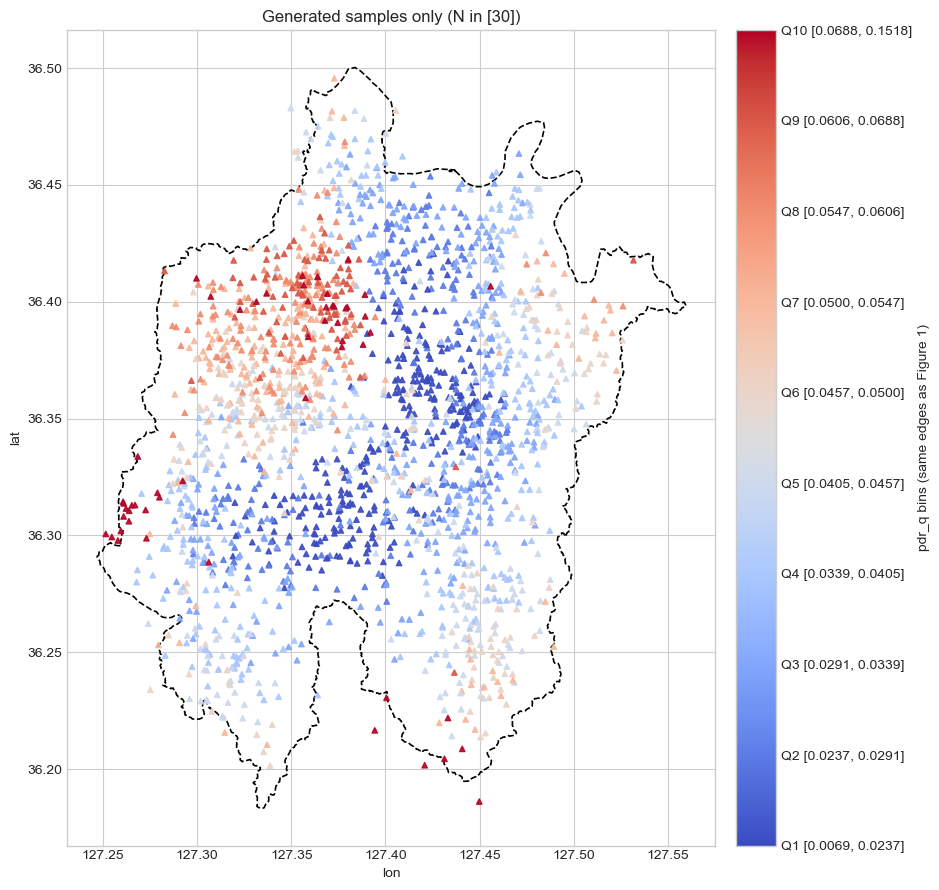

In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# =============================================
# Two-figure visualization
# 1) Real df only (N in [N_MIN, N_MAX])
# 2) Generated samples from multiple CSVs only
#    - row-wise pdr mapped to the SAME bins as Figure 1
# =============================================

N_CENTER = 30
N_DELTA = 3

N_MIN, N_MAX = N_CENTER - N_DELTA, N_CENTER + N_DELTA

# CSV path list
sample_dir = os.path.join('..', 'outputs', 'mlp_diffusion', 'resolution_n30')
SAMPLE_CSVS = sorted(glob.glob(os.path.join(sample_dir, '*.csv')))

if 'pdr_mean' not in df.columns:
    raise KeyError("df에 'pdr_mean' 컬럼이 없습니다.")
if 'N' not in df.columns:
    raise KeyError("df에 'N' 컬럼이 없습니다.")


df_base = df.copy()

# 핵심: df_base 기준으로 10구간을 '항상' 재계산
q_codes, q_edges = pd.qcut(
    df_base['pdr_mean'],
    q=10,
    labels=False,
    retbins=True,
    duplicates='drop'
)
df_base['q_idx'] = q_codes.astype(float)
nq = len(q_edges) - 1

if nq < 1:
    raise ValueError("유효한 q-bin을 만들 수 없습니다. pdr_mean 분포를 확인하세요.")

tick_labels = [f"Q{i+1} [{q_edges[i]:.4f}, {q_edges[i+1]:.4f}]" for i in range(nq)]

def overlay_daejeon_boundary(ax):
    try:
        gdf_wgs84 = gdf.set_crs(epsg=5179, allow_override=True).to_crs(epsg=4326)
        gdf_daejeon = gdf_wgs84[gdf_wgs84['CTP_ENG_NM'].str.lower() == 'daejeon']
        gdf_daejeon.boundary.plot(ax=ax, color='black', linewidth=1.2, linestyle='--')
    except Exception as e:
        print(f"[WARN] daejeon boundary overlay skipped: {e}")

# common colormap setup
cmap = plt.cm.get_cmap('coolwarm')
norm = plt.Normalize(vmin=0, vmax=max(1, nq - 1))

SCATTER_KWARGS = dict(
    cmap=cmap,
    norm=norm,
    s=15,
    alpha=0.9,
)

# ---------------------------------------------
# Figure 1: Real df only
# ---------------------------------------------
df_sample = df_base.sample(min(5000, len(df_base)), random_state=42).copy()

fig1, ax1 = plt.subplots(figsize=(11, 9))
ax1.scatter(
    df_sample['lon'],
    df_sample['lat'],
    c=df_sample['q_idx'],
    marker='s',  # 사각형
    **SCATTER_KWARGS,
)
overlay_daejeon_boundary(ax1)

sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm1.set_array([])
cbar1 = plt.colorbar(sm1, ax=ax1, pad=0.02)
cbar1.set_label('pdr_q bins (from real df_base)')
cbar1.set_ticks(range(nq))
cbar1.set_ticklabels(tick_labels)

ax1.set_title(f"Real dataset only (N in [{N_CENTER}]])")
ax1.set_xlabel('lon')
ax1.set_ylabel('lat')
plt.tight_layout()
plt.show()

# ---------------------------------------------
# Figure 2: Generated samples from SAMPLE_CSVS
# ---------------------------------------------
loaded_samples = []

for csv_path in SAMPLE_CSVS:
    # 혹시 (path, ...) 형태가 들어와도 대응
    if isinstance(csv_path, (tuple, list)):
        csv_path = csv_path[0]

    if not os.path.exists(csv_path):
        print(f"[WARN] not found: {csv_path}")
        continue

    dfg = pd.read_csv(csv_path)
    if not {'lat', 'lon', 'pdr'}.issubset(set(dfg.columns)):
        print(f"[WARN] lat/lon/pdr 컬럼 없음: {csv_path}")
        continue

    dfg = dfg.copy()

    # N 컬럼이 있으면 동일 범위 필터 적용
    if 'N' in dfg.columns:
        dfg = dfg[(dfg['N'] >= N_MIN) & (dfg['N'] <= N_MAX)]

    if len(dfg) == 0:
        print(f"[WARN] empty after N filter: {csv_path}")
        continue

    # 각 행 pdr 값을 Figure1과 동일한 q_edges로 binning
    pdr_vals = dfg['pdr'].astype(float)
    q_idx = pd.cut(
        pdr_vals,
        bins=q_edges,
        labels=False,
        include_lowest=True,
        right=True
    ).astype(float)

    # 경계 밖/NaN 처리
    q_idx = q_idx.where(
        ~q_idx.isna(),
        np.where(pdr_vals < q_edges[0], 0.0, float(nq - 1))
    )

    dfg['q_idx'] = q_idx.clip(lower=0.0, upper=float(nq - 1))

    loaded_samples.append({
        'name': os.path.basename(csv_path),
        'df': dfg,
    })

print(f"Loaded sample csv count: {len(loaded_samples)}")

fig2, ax2 = plt.subplots(figsize=(11, 9))
for i, item in enumerate(loaded_samples):
    dfg = item['df']
    ax2.scatter(
    dfg['lon'],
    dfg['lat'],
    c=dfg['q_idx'],
    marker='^',  # 삼각형
    zorder=10 + i,
    **SCATTER_KWARGS,
)

overlay_daejeon_boundary(ax2)

sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=ax2, pad=0.02)
cbar2.set_label('pdr_q bins (same edges as Figure 1)')
cbar2.set_ticks(range(nq))
cbar2.set_ticklabels(tick_labels)

ax2.set_title(f"Generated samples only (N in [{N_CENTER}])")
ax2.set_xlabel('lon')
ax2.set_ylabel('lat')
ax2.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()